# Imports

In [1]:
%pip install -q --upgrade --force-reinstall "protobuf>=6.31.1,<7"
%pip install -q --upgrade --force-reinstall tensorflow-datasets
%pip install -q --upgrade numpy scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 7.1 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 60.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 14.4 MB/s eta 0:00:

In [17]:
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore
import tensorflow_probability as tfp # type: ignore
import sklearn 
import datetime
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import cv2
import albumentations as A # type: ignore
import wandb
import kagglehub # type: ignore

# MODELS
Model = tf.keras.Model

#LAYERS
Layer = tf.keras.layers.Layer # importing Layer Class to inherit from
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization
Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Dropout =  tf.keras.layers.Dropout
RandomRotation = tf.keras.layers.RandomRotation
RandomFlip = tf.keras.layers.RandomFlip
RandomContrast = tf.keras.layers.RandomContrast
Resizing = tf.keras.layers.Resizing
Rescaling = tf.keras.layers.Rescaling

#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

# METRICS
BinaryAccuracy = tf.keras.metrics.BinaryAccuracy # For a Binary Classification Problem
FalsePositives = tf.keras.metrics.FalsePositives
FalseNegatives = tf.keras.metrics.FalseNegatives
TruePositives = tf.keras.metrics.TruePositives
TrueNegatives = tf.keras.metrics.TrueNegatives
Precision = tf.keras.metrics.Precision
Recall = tf.keras.metrics.Recall
AUC = tf.keras.metrics.AUC
binary_accuracy = tf.keras.metrics.binary_accuracy
CategoricalAccuracy = tf.keras.metrics.CategoricalAccuracy
TopKCategoricalAccuracy = tf.keras.metrics.TopKCategoricalAccuracy

# Callbacks
Callback = tf.keras.callbacks.Callback
CSVLogger = tf.keras.callbacks.CSVLogger
LearningRateScheduler = tf.keras.callbacks.LearningRateScheduler
ProgBarLogger = tf.keras.callbacks.ProgbarLogger
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint
ReduceLRonPlateau = tf.keras.callbacks.ReduceLROnPlateau

# Regularizer
L2 = tf.keras.regularizers.L2

# Distributions
Beta = tfp.distributions.Beta

# Hyperparameter Tuning
from tensorboard.plugins.hparams import api as hp
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint, WandbEvalCallback # type: ignore

from pathlib import Path
import imghdr

# Tensorflow Records
from tensorflow.train import BytesList, FloatList, Int64List
from tensorflow.train import Example, Feature, Features

# Data Management

In [18]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
human-emotions-datasethes.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
!unzip -q "/content/human-emotions-datasethes.zip" -d "/content/dataset/"

replace /content/dataset/Emotions Dataset/Emotions Dataset/test/angry/101071.jpg_rotation_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [20]:
TRAIN_DIRECTORY = '/content/dataset/Emotions Dataset/Emotions Dataset/train'
VALIDATION_DIRECTORY = '/content/dataset/Emotions Dataset/Emotions Dataset/test'

In [21]:
CONFIGURATION = {
    "BATCH_SIZE": 32,
    "IM_SIZE": 256,
    "LEARNING_RATE": 1e-3,
    "N_EPOCHS": 5,
    "DROPOUT_RATE": 0.0,
    "REGULARIZATION_RATE": 0.0,
    "N_FILTERS": 6,
    "KERNEL_SIZE": 3,
    "N_STRIDES": 1,
    "POOL_SIZE": 2,
    "N_DENSE_1": 1024,
    "N_DENSE_2": 128,
    "NUM_CLASSES": 3,
    "PATCH_SIZE": 16,
    "PROJ_DIM": 768,
    "CLASS_NAMES": ["angry", "happy", "sad"],
}
 

In [22]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIRECTORY,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99)

Found 6799 files belonging to 3 classes.


In [23]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VALIDATION_DIRECTORY,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99)

Found 2278 files belonging to 3 classes.


In [ ]:
for i in val_dataset.take(1): # taking one batch
    print(i)

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
array([[[[ 20.        ,  20.        ,  20.        ],
         [ 19.1875    ,  19.1875    ,  19.1875    ],
         [ 19.        ,  19.        ,  19.        ],
         ...,
         [ 29.125     ,  29.125     ,  29.125     ],
         [ 25.        ,  25.        ,  25.        ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.        ,  20.        ,  20.        ],
         [ 19.847656  ,  19.847656  ,  19.847656  ],
         [ 19.8125    ,  19.8125    ,  19.8125    ],
         ...,
         [ 28.820312  ,  28.820312  ,  28.820312  ],
         [ 25.660156  ,  25.660156  ,  25.660156  ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.6875    ,  20.6875    ,  20.6875    ],
         [ 21.246094  ,  21.246094  ,  21.246094  ],
         [ 21.847656  ,  21.847656  ,  21.847656  ],
         ...,
         [ 25.3125    ,  25.3125    ,  25.3125    ],
         [ 22.375     ,  22.375     ,  22.375 

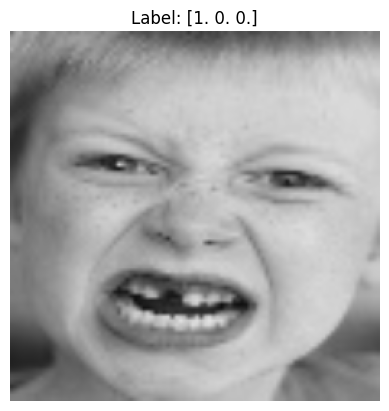

In [32]:
for image_batch, label_batch in val_dataset.take(1):
    # very first image (index 0) in the batch
    first_image = image_batch[0]/255.0
    first_label = label_batch[0].numpy()

    plt.imshow(first_image.numpy()) 
    plt.title(f"Label: {first_label}")
    plt.axis('off')

# Data Visualization

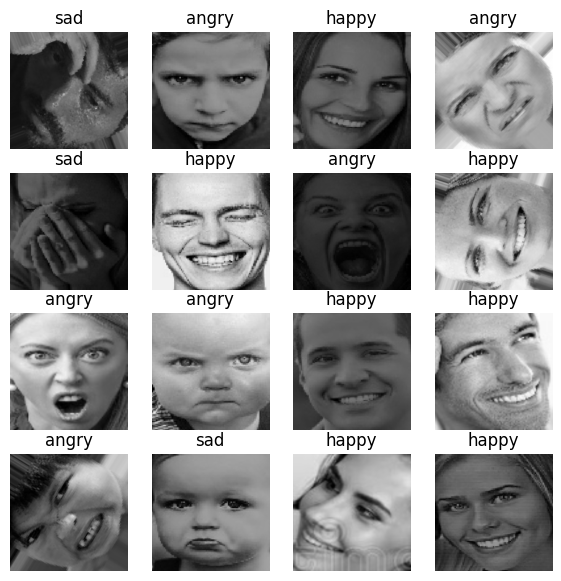

In [9]:
plt.figure(figsize = (7,7))
for images, labels in train_dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images[i]/255)
        plt.title(CONFIGURATION['CLASS_NAMES'][tf.argmax(labels[i], axis = 0).numpy()])
        plt.axis('off')

# Data Augmentation

In [8]:
augment_layers = tf.keras.Sequential([
    RandomRotation(factor=(-0.025,0.025)),# [-0.025 * 360, 0.025 * 360], to keep the rotation to 90 degrees
    RandomFlip(mode='horizontal',),
    RandomContrast(factor = 0.1)
])
def augment_layer(image, label):
    return augment_layers(image, training = True), label

## CutMix Augmentation

In [9]:
def box(lamda):
    
    r_x = tf.cast(tfp.distributions.Uniform(low=0 , high=CONFIGURATION['IM_SIZE']).sample(1)[0], dtype = tf.int32)
    r_y = tf.cast(tfp.distributions.Uniform(low=0 , high=CONFIGURATION['IM_SIZE']).sample(1)[0], dtype = tf.int32)


    r_w = tf.cast(CONFIGURATION['IM_SIZE'] * tf.math.sqrt(1-lamda), dtype = tf.int32)
    r_h = tf.cast(CONFIGURATION['IM_SIZE'] * tf.math.sqrt(1-lamda), dtype= tf.int32)

    # To get the top-left corner point
    r_x = tf.clip_by_value(r_x - r_w//2, 0, CONFIGURATION['IM_SIZE']) # 'tf.clip_by_value' - So the boxes are limited to the image - 13:23:50
    r_y = tf.clip_by_value(r_y - r_h//2, 0, CONFIGURATION['IM_SIZE'])

    # To get the bottom right point
    x_b_r = tf.clip_by_value(r_x + r_w//2, 0, CONFIGURATION['IM_SIZE']) # x bottom right
    y_b_r = tf.clip_by_value(r_y + r_h//2, 0, CONFIGURATION['IM_SIZE'])

    # Calculations done incase the box was out of bounds of the image
    r_w = x_b_r - r_x

    if(r_w == 0):
        r_w = 1

    r_h = y_b_r - r_y

    if(r_h == 0):
        r_h = 1

    return r_y, r_x, r_h, r_w

In [10]:
def cutmix(train_dataset_1, train_dataset_2):
    (image_1, label_1), (image_2, label_2) = train_dataset_1, train_dataset_2

    lamda = tfp.distributions.Beta(0.2,0.2)
    lamda = lamda.sample(1)[0]

    r_y, r_x, r_h, r_w = box(lamda)


    
    crop_2 = tf.image.crop_to_bounding_box(image_2 ,r_y, r_x, r_h, r_w)
    pad_2 = tf.image.pad_to_bounding_box(crop_2,r_y, r_x,  CONFIGURATION['IM_SIZE'],  CONFIGURATION['IM_SIZE'])

    crop_1 = tf.image.crop_to_bounding_box(image_1, r_y, r_x, r_h, r_w)
    pad_1 = tf.image.pad_to_bounding_box(crop_1, r_y, r_x,  CONFIGURATION['IM_SIZE'],  CONFIGURATION['IM_SIZE'])

    image = image_1 - pad_1 + pad_2

    lamda = tf.cast(1 - (r_w*r_h)/( CONFIGURATION['IM_SIZE']* CONFIGURATION['IM_SIZE']), dtype=tf.float32)
    label = lamda*tf.cast(label_1, dtype=tf.float32) + (1-lamda)*tf.cast(label_2, dtype=tf.float32)
    
    return image, label

In [11]:
train_dataset_1 = train_dataset.map(augment_layer, num_parallel_calls = tf.data.AUTOTUNE)
train_dataset_2 = train_dataset.map(augment_layer, num_parallel_calls = tf.data.AUTOTUNE)

mixed_dataset = tf.data.Dataset.zip(train_dataset_1, train_dataset_2)

# Dataset Preparation

In [33]:
training_dataset = mixed_dataset.map(cutmix, num_parallel_calls=tf.data.AUTOTUNE) #.prefetch(tf.data.AUTOTUNE)
# training_datset = train_dataset.map(augment_layer, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
validation_dataset = val_dataset #.prefetch(tf.data.AUTOTUNE)

In [13]:
# These will be the layers in the MODEL
resize_rescale_layers = tf.keras.Sequential([
    Resizing(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']), 
    Rescaling(1./255),])

# TF Records

In [ ]:
# Condenses a large number of small chunks of files in to several decently large files
# Data -> PreProcess -> Augmented. We can use the augmented data when we load the model. No need to carry out augmentation again.
# Can store the augmented data in the saved file
# Parallelizes when reading the data by creating shards on different hosts

In [34]:
training_dataset = training_dataset.unbatch()
validation_dataset = validation_dataset.unbatch()

In [ ]:
def encode_image(image, label): # to convert images into bytes
    image = tf.image.convert_image_dtype(image, dtype=tf.uint8)
    image = tf.io.encode_jpeg(image)
    return image, tf.argmax(label)

In [37]:
encoded_dataset = training_dataset.map(encode_image)

In [38]:
def create_example(image, label):
    # these are our features of the shards I'm guessing
    bytes_feature = Feature(
        bytes_list=BytesList(value=[image]))

    # and these are our labels of the shards I'm guessing
    class_id = int(np.argmax(label))
    int_feature = Feature(
        int64_list=Int64List(value=[class_id]))

    example = Example(
        features=Features(feature={
            'images': bytes_feature,
            'labels': int_feature,
        }))
    return example.SerializeToString()

In [39]:
%mkdir tfrecords

In [ ]:
NUM_SHARDS = 10
PATH = 'tfrecords/tfrecords.shard_{:02d}.tfrecord'

In [41]:
# Write the records to a file.
for shard_number in range(NUM_SHARDS):
    sharded_dataset = (encoded_dataset.shard(NUM_SHARDS, shard_number).as_numpy_iterator())
    with tf.io.TFRecordWriter(PATH.format(shard_number)) as file_writer:
        for encoded_image, encoded_label in sharded_dataset:
            example = create_example(encoded_image, encoded_label)
            file_writer.write(example)


In [44]:
recons_shard_dataset = tf.data.TFRecordDataset(filenames = [PATH.format(i) for i in range(NUM_SHARDS)])

In [64]:
def parse_tfrecords(example):
    feature_description = {
        'images': tf.io.FixedLenFeature([], tf.string),
        'labels': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)
    example['images'] = tf.io.decode_jpeg(example['images'], channels = 3)
    return example['images'], example['labels']

# FINAL WORKFLOW -> Taking an example['image'] which is in bytes to 'Unsigned int'.

In [65]:
parsed_dataset = recons_shard_dataset.map(parse_tfrecords).batch(CONFIGURATION['BATCH_SIZE']).prefetch(tf.data.AUTOTUNE)

In [67]:
parsed_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [72]:
for image, label in parsed_dataset.take(1):
    print(i) 
    

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=uint8, numpy=
array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        ...,

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 2

# Modeling

In [73]:
lenet_model = tf.keras.Sequential([
    InputLayer(shape = (None, None, 3), ), # designed to accept images of any height and any width

    resize_rescale_layers,
    
    Conv2D(filters = CONFIGURATION["N_FILTERS"] , kernel_size = CONFIGURATION["KERNEL_SIZE"], strides = CONFIGURATION["N_STRIDES"] , padding='valid',
          activation = 'relu',kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"] ),

    Conv2D(filters = CONFIGURATION["N_FILTERS"]*2 + 4, kernel_size = CONFIGURATION["KERNEL_SIZE"], strides=CONFIGURATION["N_STRIDES"], padding='valid',
          activation = 'relu', kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),

    Flatten(),
    
    Dense( CONFIGURATION["N_DENSE_1"], activation = "relu", kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]),
    
    Dense( CONFIGURATION['N_DENSE_2'], activation = "relu", kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),

    Dense(CONFIGURATION["NUM_CLASSES"], activation = "softmax"),
])
lenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    62,981,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,118,451 (240.78 MB)

 Trainable params: 63,116,103 (240.77 MB)

 Non-trainable params: 2,348 (9.17 KB)

# Training

In [47]:
loss_function = tf.keras.losses.CategoricalCrossentropy()
# loss_function = tf.keras.losses.SparseCategoricalCrossentropy() to use when label_mode='int'
# from_logits = True if the last layer didn't have a 'softmax' activation function
metrics = [CategoricalAccuracy(name = 'accuracy'), TopKCategoricalAccuracy(k=2, name='Top_k_Accuracy') ]

In [48]:
lenet_model.compile(optimizer= Adam(learning_rate = CONFIGURATION['LEARNING_RATE']),
                    loss = loss_function,
                    metrics = metrics)

In [50]:
History = lenet_model.fit(train_dataset,
                        validation_data=validation_dataset,
                        epochs=CONFIGURATION['N_EPOCHS'],
                        verbose=1) 

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - Top_k_Accuracy: 0.9968 - accuracy: 0.9693 - loss: 0.0735 - val_Top_k_Accuracy: 0.7880 - val_accuracy: 0.5566 - val_loss: 1.5168
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - Top_k_Accuracy: 0.9984 - accuracy: 0.9741 - loss: 0.0635 - val_Top_k_Accuracy: 0.7511 - val_accuracy: 0.4763 - val_loss: 1.9054
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - Top_k_Accuracy: 0.9982 - accuracy: 0.9763 - loss: 0.0553 - val_Top_k_Accuracy: 0.7700 - val_accuracy: 0.5408 - val_loss: 1.6005
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - Top_k_Accuracy: 0.9988 - accuracy: 0.9810 - loss: 0.0452 - val_Top_k_Accuracy: 0.7586 - val_accuracy: 0.4183 - val_loss: 2.6053
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - Top_k_Accuracy: 0.9984 - accuracy: 0.9812 - loss: 0.0439 - val_Top_k_Accuracy: 0.8582 - val_accuracy: 0.6260 - val_loss: 1.2439


<class 'keras.src.callbacks.history.History'>
dict_keys(['Top_k_Accuracy', 'accuracy', 'loss', 'val_Top_k_Accuracy', 'val_accuracy', 'val_loss'])


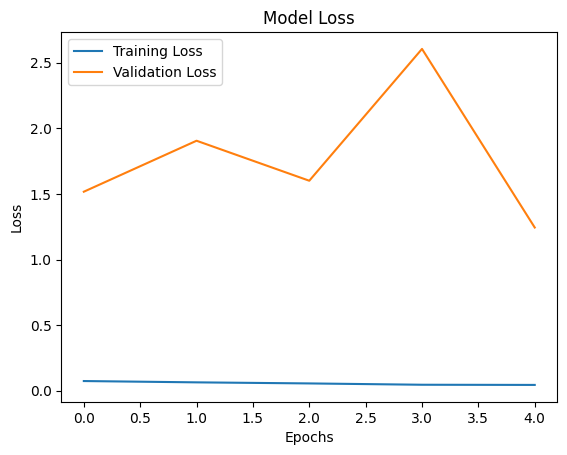

In [51]:
print(type(History))
print(History.history.keys())
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

<class 'keras.src.callbacks.history.History'>
dict_keys(['Top_k_Accuracy', 'accuracy', 'loss', 'val_Top_k_Accuracy', 'val_accuracy', 'val_loss'])


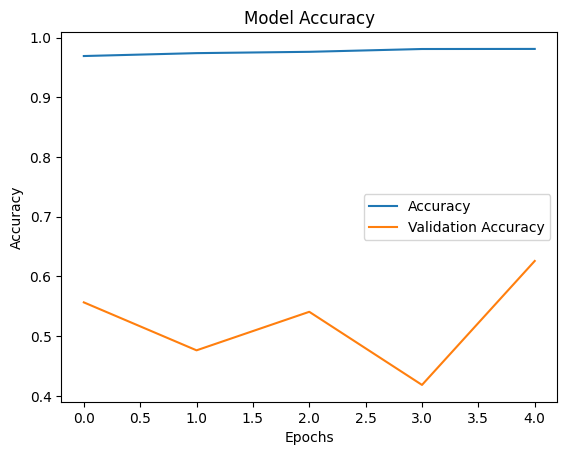

In [52]:
print(type(History))
print(History.history.keys())
plt.plot(History.history['accuracy'], label='Accuracy') 
plt.plot(History.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

# Evaluation

In [53]:
lenet_model.evaluate(validation_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - Top_k_Accuracy: 0.8582 - accuracy: 0.6260 - loss: 1.2439


[1.243868350982666, 0.625987708568573, 0.858208954334259]

# Testing

angry


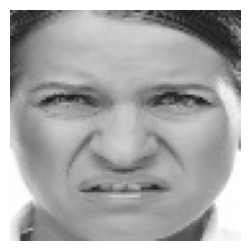

In [54]:
test_image = cv2.imread('/content/dataset/Emotions Dataset/Emotions Dataset/test/sad/123731.jpg')
im = tf.constant(test_image, dtype=tf.float32) # convert to a tensor
im = tf.expand_dims(im, axis = 0)
plt.figure(figsize = (3,3))
plt.imshow(test_image)
plt.axis('off')
print(CONFIGURATION['CLASS_NAMES'][tf.argmax(lenet_model(im), axis = 1).numpy()[0]])


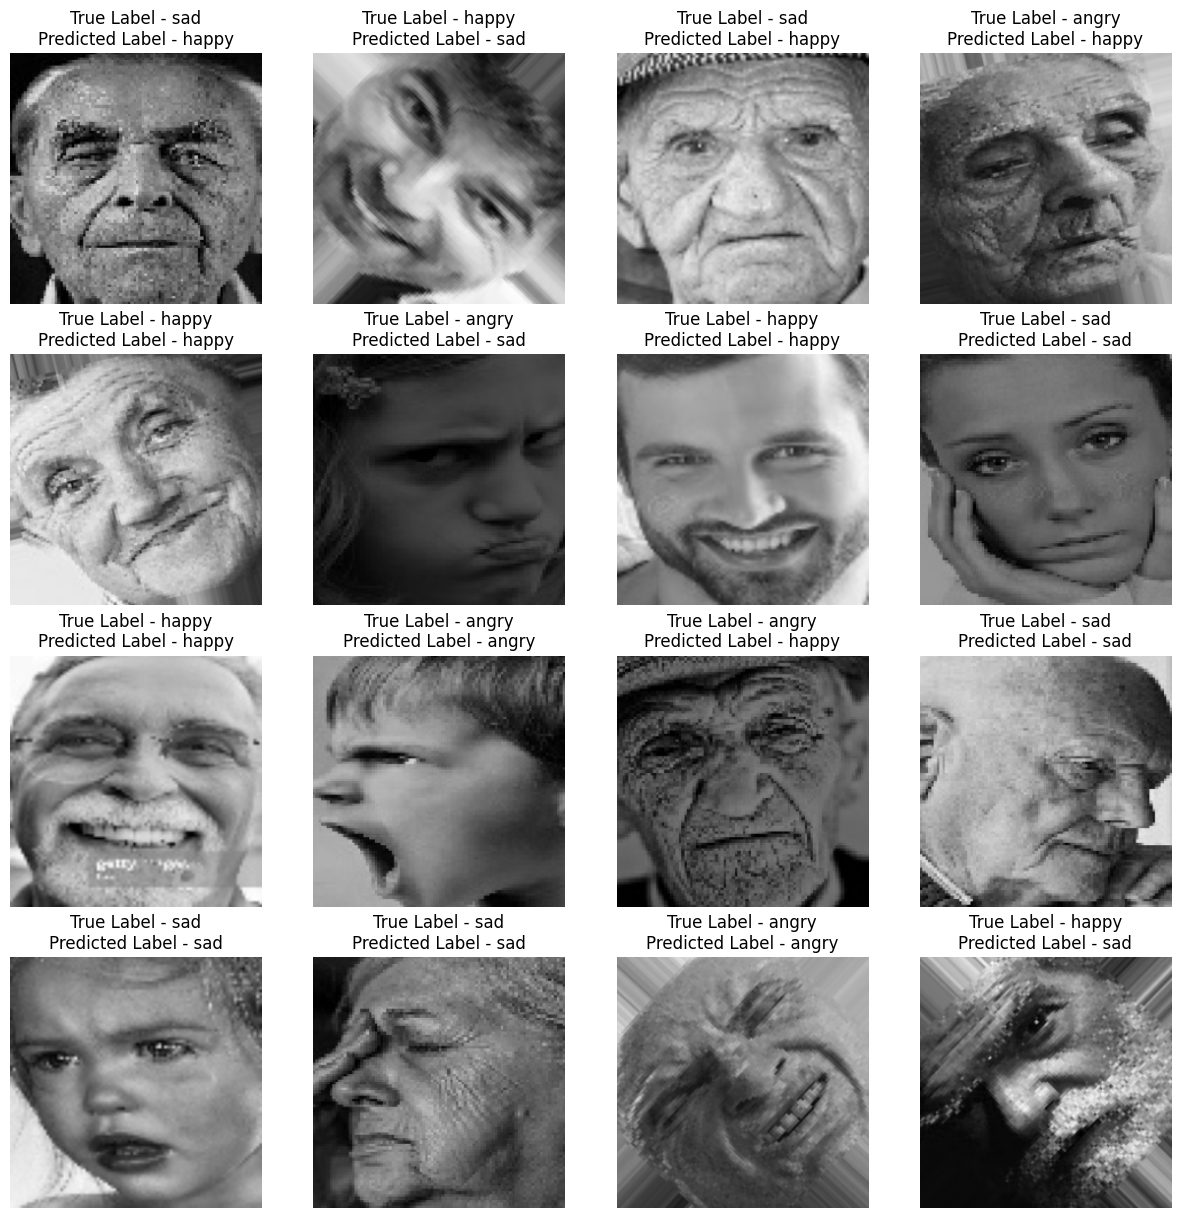

In [55]:
plt.figure(figsize = (15,15))
for images, labels in validation_dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images[i]/255)
        plt.title('True Label - ' + CONFIGURATION['CLASS_NAMES'][tf.argmax(labels[i], axis = 0).numpy()]
                + '\n' + 'Predicted Label - ' + CONFIGURATION['CLASS_NAMES'][tf.argmax(lenet_model(tf.expand_dims(images[i], axis = 0)), axis =-1).numpy()[0]])
        plt.axis('off')

# Confusion Matrix

In [56]:
predicted = []
labels = []

for im, label in validation_dataset:
    predicted.append(lenet_model(im))
    labels.append(label.numpy())

In [57]:
print(np.concatenate([np.argmax(labels[:-1], axis = -1).flatten(), np.argmax(labels[-1], axis = -1).flatten()])) # class names of all batches into a 1 dimension list + all batches of 32 + the last batch
print(np.concatenate([np.argmax(predicted[:-1], axis = -1).flatten(), np.argmax(predicted[-1], axis = -1).flatten()]))

[1 0 2 ... 0 1 0]
[1 0 2 ... 0 1 0]


In [58]:
pred = np.concatenate([np.argmax(labels[:-1], axis = -1).flatten(), np.argmax(labels[-1], axis = -1).flatten()])
lab = np.concatenate([np.argmax(predicted[:-1], axis = -1).flatten(), np.argmax(predicted[-1], axis = -1).flatten()])

[[312  43  67]
 [ 79 822 124]
 [124 141 566]]


Text(0.5, 36.72222222222221, 'Predicted')

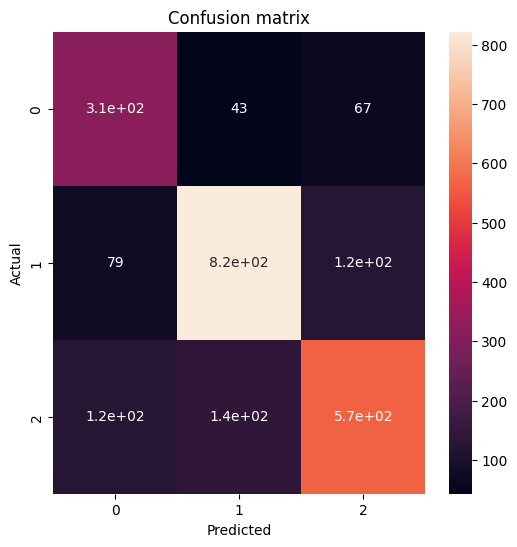

In [59]:
cm = confusion_matrix(lab, pred) 
print(cm)
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True,)
plt.title(f'Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')